In [5]:
# Imports and Setup
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt
# Ensure the workspace root is on sys.path so local packages (like `utils`) are importable
cwd = Path.cwd()
project_root = None
for parent in [cwd] + list(cwd.parents):
    if (parent / 'utils').is_dir() or (parent / '.git').exists():
        project_root = str(parent)
        break
if project_root is None:
    project_root = str(cwd)
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from utils.plotting import analyze_single_set_performance, set_plot_style

# Available data paths
available_paths = ['/space/gzanardini/tuh/tuh_ss_bg_noieds/']

# EMC good experiments paths
# ['/space/gzanardini/emc/emc_background',
#  '/space/gzanardini/emc/emc_singleset_final/',
#  '/space/gzanardini/emc/emc_hypervent/']

# TUH good experiments paths
# ['/space/gzanardini/tuh/tuh_ss_bg/',
#  '/space/gzanardini/tuh/tuh_ss_bg_noieds/',
#  '/space/gzanardini/tuh/tuh_singleset_final/',
#  '/space/gzanardini/tuh/tuh_singleset_noied_final/']

feature_types = ['spectral', 'cwt', 'dwt', 'mst', 'sst', 'cc', 'plv', 'gcc', 'gplv', 'utm', 'sa', 'sr']
feature_names = {
    'spectral': 'Spectral',
    'cc': 'CC',
    'cwt': 'CWT',
    'dwt': 'DWT',
    'gcc': 'GCC',
    'gplv': 'GPLV',
    'utm': 'UTM',
    'mst': 'MST',
    'sst': 'SST',
    'sa': 'SA',
    'sr': 'SR',
    'plv': 'PLV',
}

print('Available data paths:')
for i, path in enumerate(available_paths):
    print(f'{i+1}. {path}')

colors = list(plt.cm.tab10.colors) * (10 // len(plt.cm.tab10.colors) + 1)

type_to_save = 'plv'
save_dir = './paperdata/'

Available data paths:
1. /space/gzanardini/tuh/tuh_ss_bg_noieds/


In [6]:
# Shared plotting style/colors
set_plot_style('ggplot')

/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/gzanardini/miniconda3/envs/eeg/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

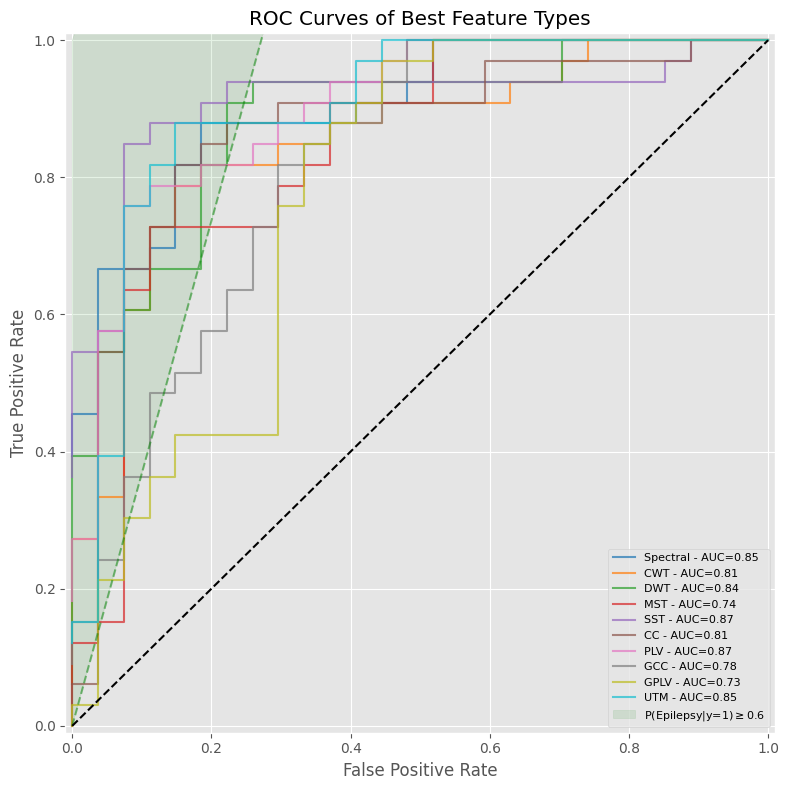

In [7]:
for path in available_paths:
    df_summary = None
    if os.path.exists(path):
        df_summary, df_best, std_df = analyze_single_set_performance(
            path,
            feature_types=feature_types,
            feature_display_names=feature_names,
            save_plots=True,
            plot_prefix=path.split('/')[-2],
            type_to_save=type_to_save,
            save_dir=save_dir,
            colors=colors,
        )